In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy.stats import linregress

sns.set_style("whitegrid")

print("Ready")

Ready


# Fund Performance Analytics

## Bluestock Mutual Fund Analytics Capstone

### Objectives

- Daily Returns
- CAGR
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy.stats import linregress

sns.set_style("whitegrid")

In [3]:
PROCESSED_PATH = Path("../data/processed")
RAW_PATH = Path("../data/raw")

fund_df = pd.read_csv(
    PROCESSED_PATH / "clean_fund_master.csv"
)

nav_df = pd.read_csv(
    PROCESSED_PATH / "clean_nav_history.csv"
)

perf_df = pd.read_csv(
    PROCESSED_PATH / "clean_performance.csv"
)

benchmark_df = pd.read_csv(
    RAW_PATH / "10_benchmark_indices.csv"
)

print("Datasets Loaded")

Datasets Loaded


In [4]:
nav_df["date"] = pd.to_datetime(
    nav_df["date"]
)

benchmark_df["date"] = pd.to_datetime(
    benchmark_df["date"]
)

nav_df.head()

,date,amfi_code,nav
0,2022-01-03,100016,520.4608
1,2022-01-04,100016,515.0971
2,2022-01-05,100016,521.7239
3,2022-01-06,100016,515.7880
4,2022-01-07,100016,515.1639


## Daily Return Calculation

In [5]:
nav_df = nav_df.sort_values(
    ["amfi_code","date"]
)

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_df.head()

,date,amfi_code,nav,daily_return
0,2022-01-03,100016,520.4608,NaN
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210


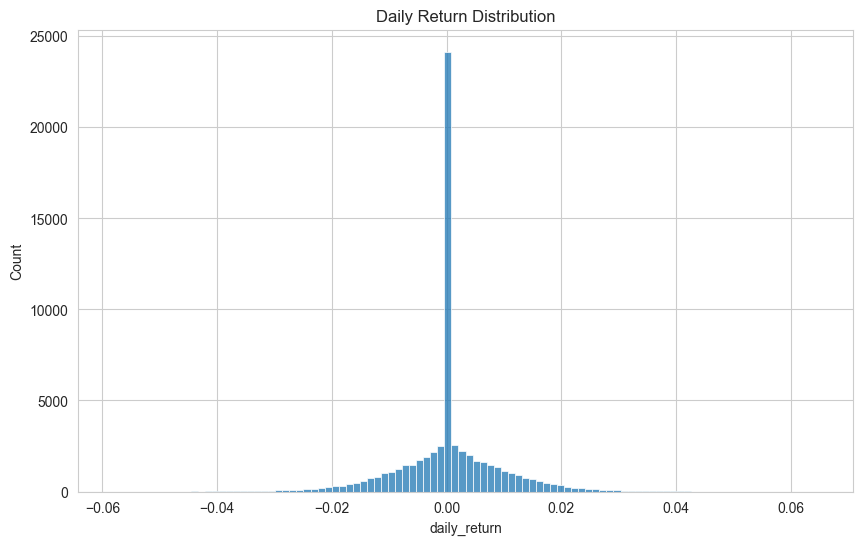

In [6]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_df["daily_return"].dropna(),
    bins=100
)

plt.title(
    "Daily Return Distribution"
)

plt.show()

## CAGR Analysis

In [7]:
cagr_results = []

for code in nav_df["amfi_code"].unique():

    temp = nav_df[
        nav_df["amfi_code"] == code
    ].sort_values("date")

    start_nav = temp["nav"].iloc[0]
    end_nav = temp["nav"].iloc[-1]

    years = (
        temp["date"].max()
        - temp["date"].min()
    ).days / 365.25

    cagr = (
        (end_nav/start_nav)
        ** (1/years)
        - 1
    ) * 100

    cagr_results.append(
        [code,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr_pct"
    ]
)

cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.637074
1,100025,4.458210
2,100033,30.123153
3,101206,23.538361
4,101207,7.938765


## Sharpe Ratio

In [8]:
RF = 0.065

sharpe_results = []

for code in nav_df["amfi_code"].unique():

    temp = nav_df[
        nav_df["amfi_code"] == code
    ]

    annual_return = (
        temp["daily_return"]
        .mean()
        * 252
    )

    annual_std = (
        temp["daily_return"]
        .std()
        * np.sqrt(252)
    )

    sharpe = (
        annual_return - RF
    ) / annual_std

    sharpe_results.append(
        [code,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.068224
30,120843,0.965561
36,148569,0.919047
25,120505,0.883256
19,119551,0.860977


In [9]:
sortino_results = []

for code in nav_df["amfi_code"].unique():

    temp = nav_df[
        nav_df["amfi_code"] == code
    ]

    downside = temp[
        temp["daily_return"] < 0
    ]["daily_return"]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        temp["daily_return"]
        .mean()
        * 252
    )

    sortino = (
        annual_return - RF
    ) / downside_std

    sortino_results.append(
        [code,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.472822
1,100025,-1.461220
2,100033,1.144216
3,101206,1.063909
4,101207,0.075668


## Alpha and Beta Analysis

In [10]:
print(
    benchmark_df["index_name"]
    .unique()
)

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [11]:
nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [12]:
alpha_beta = []

for code in nav_df["amfi_code"].unique():

    fund = nav_df[
        nav_df["amfi_code"] == code
    ][["date","daily_return"]]

    merged = pd.merge(
        fund,
        nifty100[
            ["date","benchmark_return"]
        ],
        on="date"
    )

    merged = merged.dropna()

    if len(merged) > 20:

        slope, intercept, r, p, se = (
            linregress(
                merged["benchmark_return"],
                merged["daily_return"]
            )
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta.append(
            [code,alpha,beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289
